<a href="https://colab.research.google.com/github/ab110404/MAT422/blob/main/HW2.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HW 2.4

2.4.1. MLE for random samples
- The example I will be using is; suppose the following values are a random sample from a normal distribution:
- x= [4, 5, 6, 7, 8]
- I will assume the standard deviation is known and use maximum likelihood estimation to estimate the unknown population mean 𝜇.
- For a normal distribution, the MLE of 𝜇 should equal the sample mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([4, 5, 6, 7, 8])
sample_mean = np.mean(X)
print("Sample:", X)
print("Sample mean =", sample_mean)

Sample: [4 5 6 7 8]
Sample mean = 6.0


- For a normal random sample, the likelihood is the product of the probability density values for all observations in the sample.
- I will now calculate the likelihood for different possible values of 𝜇 while keeping the standard deviation fixed at 𝜎 =1.

In [3]:
sigma = 1

def likelihood(mu, data):
  values = (1 / (np.sqrt(2 * np.pi) * sigma)) * \
            np.exp(-((data - mu)**2) / (2 * sigma**2))
  return np.prod(values)

- The MLE is the value of 𝜇 that produces the largest likelihood.
- I will compare several possible values of 𝜇 around the sample mean.

In [4]:
mu_values = [4, 5, 6, 7, 8]

for mu in mu_values:
  L = likelihood(mu, X)
  print("𝜇 =", mu, "Likelihood =", L)

𝜇 = 4 Likelihood = 3.091242677052448e-09
𝜇 = 5 Likelihood = 5.589097873487533e-06
𝜇 = 6 Likelihood = 6.808915108954251e-05
𝜇 = 7 Likelihood = 5.5890978734875325e-06
𝜇 = 8 Likelihood = 3.091242677052448e-09


- To verify the MLE, I will evaluate the likelihood over many possible values of 𝜇 and determine which value produces the maximum likelihood.

In [5]:
mu_range = np.linspace(3, 9, 1000)
likelihoods = np.array([likelihood(mu, X) for mu in mu_range])
mu_mle = mu_range[np.argmax(likelihoods)]
print("Sample mean =", sample_mean)
print("MLE of 𝜇 =", mu_mle)

Sample mean = 6.0
MLE of 𝜇 = 6.003003003003003


- The likelihood function can also be plotted against possible values of 𝜇.
- The highest point of the likelihood curve represents the maximum likelihood estimate.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120583 (\N{MATHEMATICAL ITALIC SMALL MU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


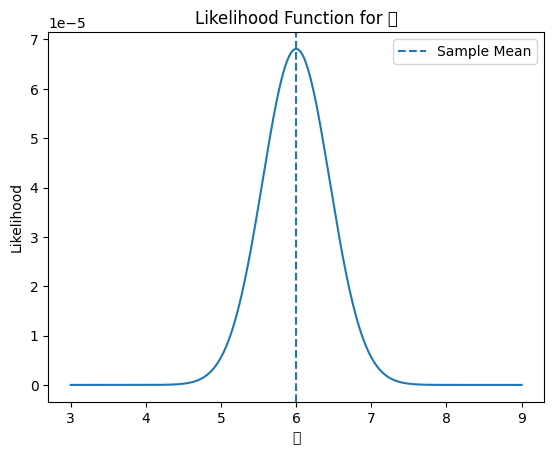

In [6]:
plt.plot(mu_range, likelihoods)
plt.axvline(sample_mean, linestyle="--", label="Sample Mean")
plt.xlabel("𝜇")
plt.ylabel("Likelihood")
plt.title("Likelihood Function for 𝜇")
plt.legend()
plt.show()

Conclusion:
- Maximum likelihood estimation chooses the parameter value that makes the observed data most likely. For this normal random sample, the sample mean was X=6.
- This example verifies that the maximum likelihood estimator of the mean of a normal distribution is 𝜇 = X.

2.4.2. Linear regression
- Linear regression models the relationship between an input variable x and an output variable y.

In [7]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.2, 3.9, 6.1, 7.8, 10.2])
print("x values:", x)
print("y values:", y)

x values: [1 2 3 4 5]
y values: [ 2.2  3.9  6.1  7.8 10.2]


- The data follows a linear relationship, but the points don't fall exactly on one line because of random error.
- Now, I will find the regression coefficients 𝛽0 and 𝛽1.

In [9]:
A = np.column_stack((np.ones(len(x)), x))
beta = np.linalg.lstsq(A, y, rcond=None)[0]
beta_0 = beta[0]
beta_1 = beta[1]
print("𝛽0 =", beta_0)
print("𝛽1 =", beta_1)

𝛽0 = 0.06999999999999823
𝛽1 = 1.9899999999999998


- The slope 𝛽1 describes the change in the predicted value of y for each one-unit increase in x.

In [10]:
y_hat = A @ beta
print("Actual y value:")
print(y)
print("\nPredicted y values:")
print(y_hat)

Actual y value:
[ 2.2  3.9  6.1  7.8 10.2]

Predicted y values:
[ 2.06  4.05  6.04  8.03 10.02]


- The predicted values are close to the observed values, but they aren't exactly equal. The difference between the actual and predicted values are called residuals or errors.

In [11]:
residuals = y - y_hat
print("Residuals:")
print(residuals)
print("\nSum of squared errors:")
print(np.sum(residuals**2))

Residuals:
[ 0.14 -0.15  0.06 -0.23  0.18]

Sum of squared errors:
0.13099999999999987


In [12]:
sigma = np.std(residuals)
likelihood_values = (
    1 / (sigma * np.sqrt(2 * np.pi))
) * np.exp(-(residuals**2) / (2 * sigma**2))

likelihood = np.prod(likelihood_values)
print("Estimated 𝜎 =", sigma)
print("Likelihood =", likelihood)

Estimated 𝜎 = 0.16186414056238638
Likelihood = 7.465534315471885


- The likelihood is obtained by multiplying the normal probability density values associated with the observations.

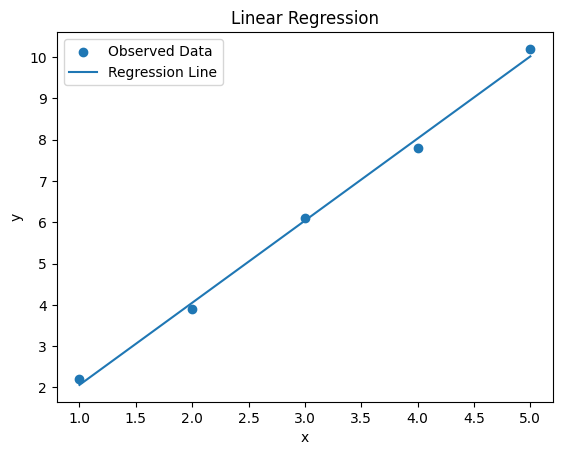

In [13]:
plt.scatter(x, y, label="Observed Data")
plt.plot(x, y_hat, label="Regression Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.show()

Conclusion:

- Linear regression finds coefficients that produce predicted values close to the observed data.
- Under this normal-error assumption, maximizing the likelihood is equivalent to minimizing the sum of squared errors. So, linear regression can also be interpreted from a maximum likelihood point of view. Overall, both examples explained each section step by step.